In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns
plt.rc('font', family='Malgun Gothic')

In [3]:
df = pd.read_csv(r"cleansed_airbnb.csv")

# 테이블 확인

In [4]:
#테이블 기본 구조 확인 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18890 entries, 0 to 18889
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0.1                                  18890 non-null  int64  
 1   Unnamed: 0                                    18890 non-null  int64  
 2   id                                            18890 non-null  int64  
 3   source                                        18890 non-null  object 
 4   name                                          18890 non-null  object 
 5   description                                   18519 non-null  object 
 6   neighborhood_overview                         10345 non-null  object 
 7   host_id                                       18890 non-null  int64  
 8   host_name                                     18871 non-null  object 
 9   host_since                                    18871 non-null 

In [5]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'id', 'source', 'name', 'description',
       'neighborhood_overview', 'host_id', 'host_name', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availabi

In [6]:
#테이블의 행과 열 갯수 반환
df.shape

(18890, 73)

# 테이블 결측치 확인 & 필요없는 값 버리기& price 숫자 형태로 바꾸기

In [7]:
#테이블 결측치 확인
pd.set_option('display.max_rows', None)
df.isnull().sum()

Unnamed: 0.1                                        0
Unnamed: 0                                          0
id                                                  0
source                                              0
name                                                0
description                                       371
neighborhood_overview                            8545
host_id                                             0
host_name                                          19
host_since                                         19
host_location                                    4241
host_about                                       7792
host_response_time                               4174
host_response_rate                               4174
host_acceptance_rate                             3264
host_is_superhost                                 341
host_neighbourhood                               3992
host_listings_count                                19
host_total_listings_count   

In [8]:
df_copy = df

In [9]:
#인덱스와 동일
df = df.drop('Unnamed: 0', axis=1)


In [10]:
#모든 행에 같은 값
df = df.drop('source', axis=1)

In [12]:
#결측치가 많고 필요 없는 열
df = df.drop(['license', 'neighbourhood'], axis = 1)

In [13]:
#리뷰가 하나도 없는(numbers): 리뷰를 받은 적이 없음 & (reiviews_per_month 부터 관련 데이터 다 결측치) 
df_no_review = df[df['first_review'].isnull()]


In [14]:

df['first_review'] = df['first_review'].fillna('no rating')
df['last_review'] = df['last_review'].fillna('no rating')
df['review_scores_rating'] = df['review_scores_rating'].fillna('no rating')
df['review_scores_accuracy'] = df['review_scores_accuracy'].fillna('no rating')
df['review_scores_cleanliness'] = df['review_scores_cleanliness'].fillna('no rating')
df['review_scores_checkin'] = df['review_scores_checkin'].fillna('no rating')
df['review_scores_communication'] = df['review_scores_communication'].fillna('no rating')
df['review_scores_location'] = df['review_scores_location'].fillna('no rating')
df['review_scores_value'] = df['review_scores_value'].fillna('no rating')
df['reviews_per_month'] = df['reviews_per_month'].fillna('no rating')

In [15]:
df.isnull().sum()

Unnamed: 0.1                                       0
id                                                 0
name                                               0
description                                      371
neighborhood_overview                           8545
host_id                                            0
host_name                                         19
host_since                                        19
host_location                                   4241
host_about                                      7792
host_response_time                              4174
host_response_rate                              4174
host_acceptance_rate                            3264
host_is_superhost                                341
host_neighbourhood                              3992
host_listings_count                               19
host_total_listings_count                         19
host_verifications                                19
host_has_profile_pic                          

In [16]:
df['price'] = (
    df['price']
    .astype(str)
    .str.replace('[\$,]', '', regex=True)
    .astype(float)
)

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
C:\Users\user\AppData\Local\Temp\ipykernel_5464\4008915164.py:4: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('[\$,]', '', regex=True)


In [17]:
df['host_response_rate'] = df['host_response_rate'].str.replace('%', '').astype(float)
df['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%', '').astype(float)

# 이상치 확인 및 제거

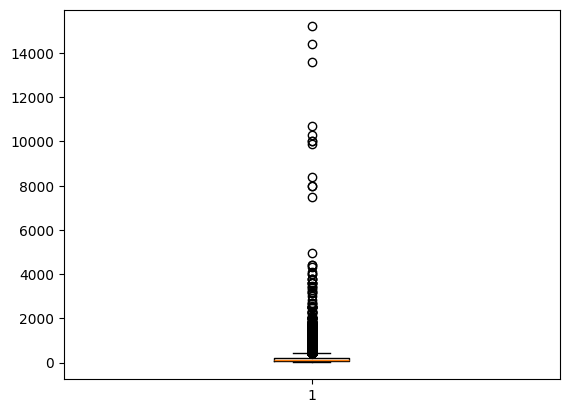

In [18]:
#이상치 
plt.boxplot(df['price'])
plt.show()

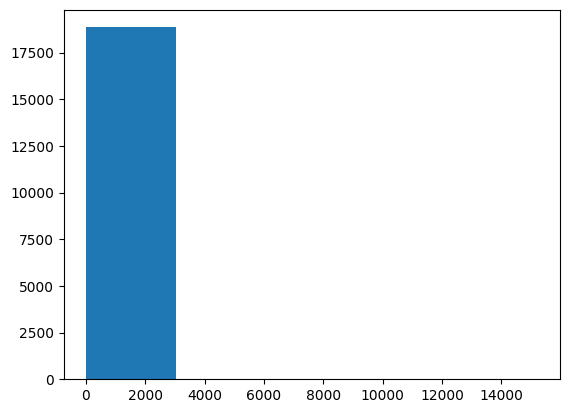

In [19]:
plt.hist(df['price'], bins = 5)
plt.show()

In [20]:
df['log_price'] = np.log(df['price'])
df['log_price'].head()

0    5.298317
1    4.406719
2    6.639876
3    4.934474
4    4.867534
Name: log_price, dtype: float64

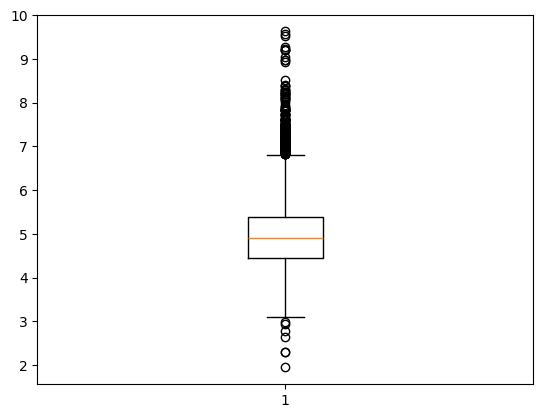

In [21]:
plt.boxplot(df['log_price'])
plt.show()

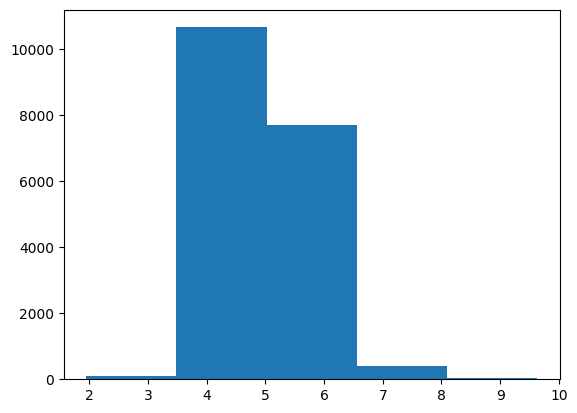

In [22]:
plt.hist(df['log_price'], bins = 5)
plt.show()

In [23]:
# IQR

df1 = df[['log_price']]

q3 = df1['log_price'].quantile(0.75) 
q1 = df1['log_price'].quantile(0.25)

iqr = q3 - q1
q3, q1, iqr

def is_outlier(df1):
    score = df1['log_price']
    if score > q3 + (1.5 * iqr) or score < q1 - (1.5 * iqr):
        return '이상치'
    else:
        return '이상치아님'

In [24]:
df['이상치여부'] = df.apply(is_outlier, axis = 1)

In [25]:
df.groupby('이상치여부').size()

이상치여부
이상치        269
이상치아님    18621
dtype: int64

In [26]:
# z-score
df2 = df[['log_price']]

df2['zscore'] =  StandardScaler().fit_transform(df2)
df2['zscore'].head()

C:\Users\user\AppData\Local\Temp\ipykernel_5464\567952397.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zscore'] =  StandardScaler().fit_transform(df2)


0    0.484450
1   -0.727126
2    2.307469
3   -0.009970
4   -0.100933
Name: zscore, dtype: float64

In [27]:

df['zscore이상치여부'] = df2['zscore'].apply(lambda x: 'z이상치' if ( x < -3 or x > 3) else 'z이상치아님')
df.groupby('zscore이상치여부', dropna=False).size()

zscore이상치여부
z이상치        138
z이상치아님    18752
dtype: int64

In [28]:
#iqr - zscore
df_outlier = df[(df['이상치여부'] == '이상치') & (df['zscore이상치여부'] == 'z이상치')]
df_outlier.head()

,Unnamed: 0.1,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,...,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price,이상치여부,zscore이상치여부
113,113,174966,Luxury 2Bed/2.5Bath Central Park View,DETAILS: Designer-decorated luxury two bedroo...,NaN,836168,Henry,2011-07-18,"New York, NY",Henry prides himself on offering superb accomm...,...,4.72,f,10,10,0,0,0.16,7.824046,이상치,z이상치
347,347,664047,Lux 2Bed/2.5Bath Central Park Views,DETAILS: Designer-decorated luxury two bedroo...,NaN,836168,Henry,2011-07-18,"New York, NY",Henry prides himself on offering superb accomm...,...,4.68,f,10,10,0,0,0.39,7.824046,이상치,z이상치
700,700,1976123,Huge Loft with Private Entrance,1st Floor Loft with your own private entrance....,"Best area , Soho , Noho East and West Village...",6547579,Josh,2013-05-23,"New York, NY",Musician,...,4.35,f,1,1,0,0,0.17,7.600402,이상치,z이상치
757,757,2261367,brooklyn 14 bedroom gated community,One of a kind in Brooklyn! A huge home it inc...,Sea Gate is a hidden gem. In the summer the o...,10416706,Pearl,2013-12-03,"New York, United States",NaN,...,4.62,f,1,1,0,0,0.14,7.615298,이상치,z이상치
995,995,3979611,Located at the heart of Manhattan,10 mins walking distance from...<br />- Times ...,* Premium Location – located in Midtown steps ...,19407840,Peng,2014-08-03,"New York, NY",I am an artist,...,4.24,f,1,1,0,0,0.24,7.244228,이상치,z이상치


In [29]:
idx = df[(df['이상치여부'] == '이상치') & (df['zscore이상치여부'] == 'z이상치')].index
df.drop(idx , inplace=True)

In [30]:
df.loc[(df['이상치여부'] == '이상치') & (df['log_price'] < q1 - 1.5 * iqr), 'log_price'] = q1
df.loc[(df['이상치여부'] == '이상치') & (df['log_price'] > q3 + 1.5 * iqr), 'log_price'] = q3

# 숙소 특성

## 지역

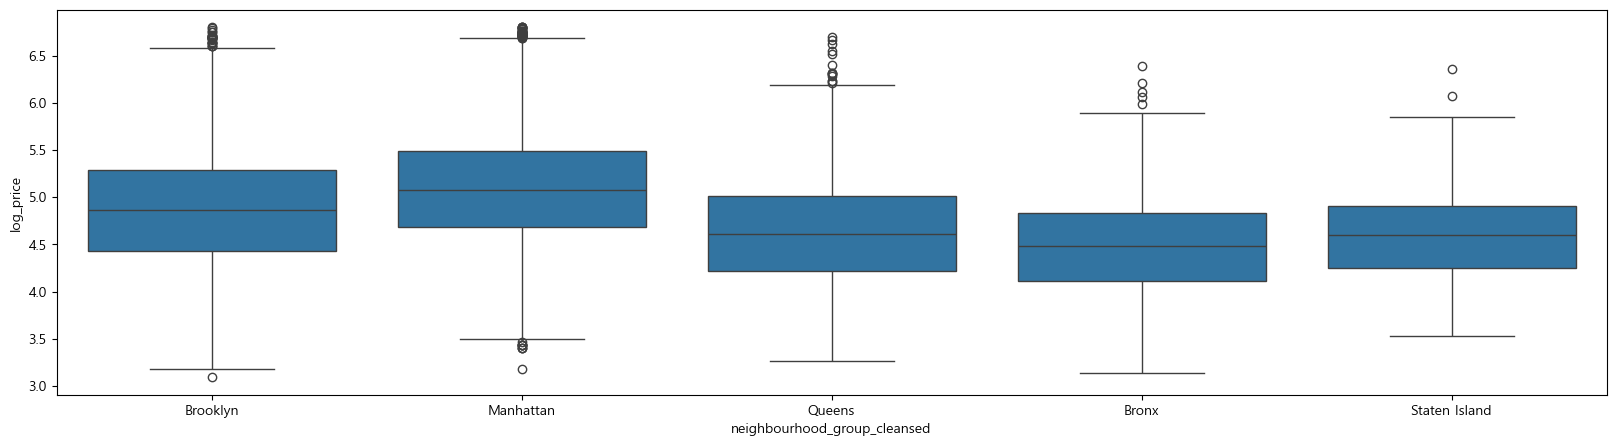

In [138]:
plt.figure(figsize=(20, 5))
sns.boxplot(x="neighbourhood_group_cleansed", y='log_price', data=df)
plt.show()

In [32]:
#neighbourhood_group_cleansed    

neighbor_pivot = pd.pivot_table(df, index='neighbourhood_group_cleansed', values='price', aggfunc= 'mean')
neighbor_pivot

,price
neighbourhood_group_cleansed,
Bronx,109.244444
Brooklyn,159.654926
Manhattan,224.615985
Queens,123.928347
Staten Island,124.121711


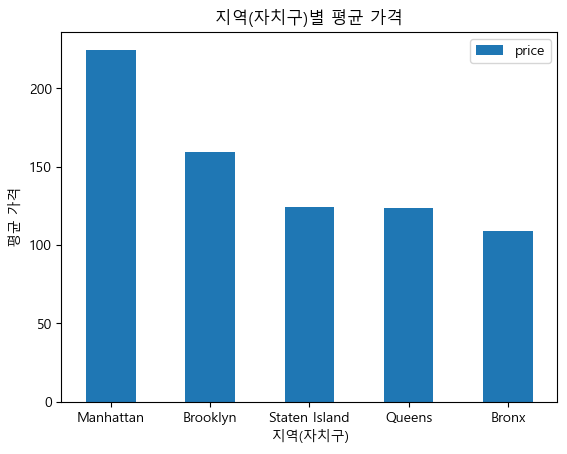

In [139]:
neighbor_pivot.sort_values(by='price',ascending=False).plot(kind='bar')
plt.title('지역(자치구)별 평균 가격')
plt.xlabel('지역(자치구)')
plt.ylabel('평균 가격')
plt.xticks(rotation=0) 
plt.show()

In [34]:
from scipy.stats import shapiro
pd.set_option('display.float_format', lambda x: f'{x}')

groups = df.groupby('neighbourhood_group_cleansed')['log_price']

for name, group in groups:
    stat, p = shapiro(group)
    print(f"{name} → W={stat:.4f}, p-value={p:.4e}")

Bronx → W=0.9840, p-value=4.8701e-08
Brooklyn → W=0.9918, p-value=2.5752e-19
Manhattan → W=0.9976, p-value=1.0207e-09
Queens → W=0.9904, p-value=7.7038e-14
Staten Island → W=0.9828, p-value=1.0312e-03


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6729.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7682.
  res = hypotest_fun_out(*samples, **kwds)


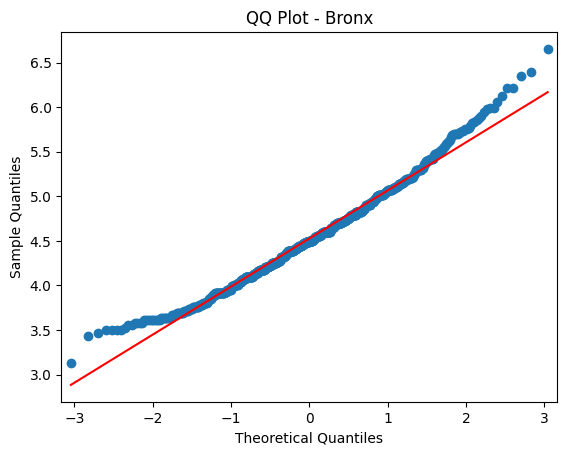

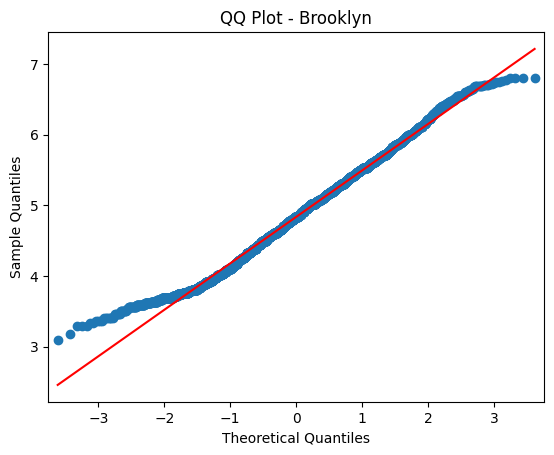

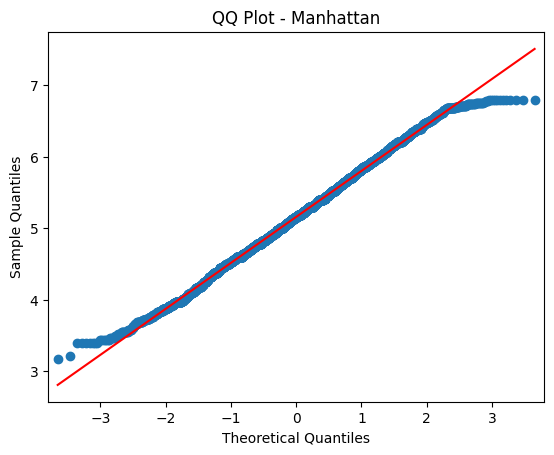

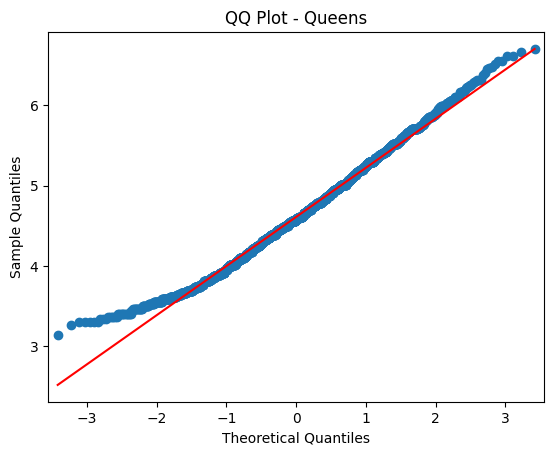

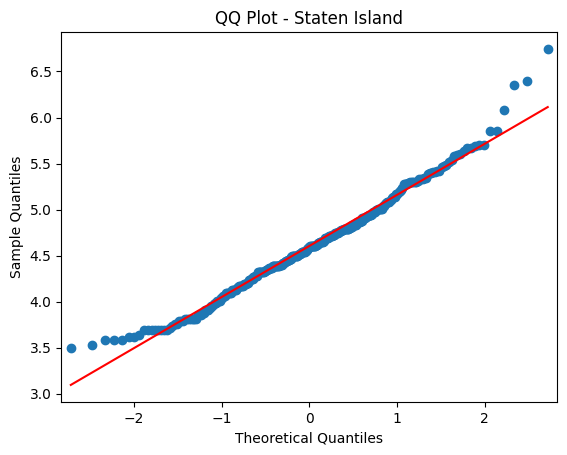

In [35]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

for name, group in df.groupby('neighbourhood_group_cleansed')['log_price']:
    sm.qqplot(group, line='s')
    plt.title(f"QQ Plot - {name}")
    plt.show()

In [36]:
#등분산성 검정 -> 위반
from scipy.stats import levene

groups = []
for name, g in df.groupby('neighbourhood_group_cleansed'):
    arr = g['log_price'].values
    groups.append(arr)

stat, p = levene(*groups)
print("Levene stat:", stat, "p-value:", p)


Levene stat: 22.786931900336906 p-value: 8.347638637131492e-19


In [37]:
#welch anova 검정 -> 유의미한 차이
import pingouin as pg

welch = pg.welch_anova(
    dv='log_price',
    between='neighbourhood_group_cleansed',
    data=df
)
print(welch)

                         Source  ddof1              ddof2                 F  \
0  neighbourhood_group_cleansed      4 1772.5773321980341 632.9672523636187   

   p-unc                 np2  
0    0.0 0.11195638652371424  


In [38]:
#  Games Howell's test
# 사후검정 

result = pg.pairwise_gameshowell(dv = 'log_price', between = 'neighbourhood_group_cleansed', data = df)
print(result)

           A              B           mean(A)           mean(B)  \
0      Bronx       Brooklyn 4.526377707538494 4.834403401933834   
1      Bronx      Manhattan 4.526377707538494  5.16024452497486   
2      Bronx         Queens 4.526377707538494 4.609499387448676   
3      Bronx  Staten Island 4.526377707538494 4.604417463131507   
4   Brooklyn      Manhattan 4.834403401933834  5.16024452497486   
5   Brooklyn         Queens 4.834403401933834 4.609499387448676   
6   Brooklyn  Staten Island 4.834403401933834 4.604417463131507   
7  Manhattan         Queens  5.16024452497486 4.609499387448676   
8  Manhattan  Staten Island  5.16024452497486 4.604417463131507   
9     Queens  Staten Island 4.609499387448676 4.604417463131507   

                  diff                   se                   T  \
0  -0.3080256943953401 0.020119313846464787 -15.309950266990047   
1   -0.633866817436366  0.01986319898976049  -31.91161795051871   
2  -0.0831216799101826 0.021411065651788175 -3.88218322534733

Games–Howell 사후검정 결과, Manhattan은 다른 모든 지역(Brooklyn, Queens, Staten Island, Bronx)에 비해 평균 log_price가 유의하게 높았다(p < 0.001). Brooklyn 역시 Bronx 및 Queens 등과 비교해 유의하게 높은 가격대를 보였다(p < 0.001). Bronx는 전체 지역 중 가장 낮은 가격을 보였으며, Queens와 Staten Island 간에는 통계적으로 유의한 차이가 나타나지 않았다(p = 0.99).

## 지역별 평균 수익

In [111]:
#지역별 평균 수익 

df['revenue'] = df['price'] * df['estimated_occupancy_l365d']
df['log_revenue'] = df['log_price'] * df['estimated_occupancy_l365d']
revenue_pivot = pd.pivot_table(df, index='neighbourhood_group_cleansed', values='revenue', aggfunc= 'mean')
revenue_pivot

,revenue
neighbourhood_group_cleansed,
Bronx,7410.35391566265
Brooklyn,15937.578060651442
Manhattan,20534.91877353416
Queens,11684.102771362586
Staten Island,10136.4


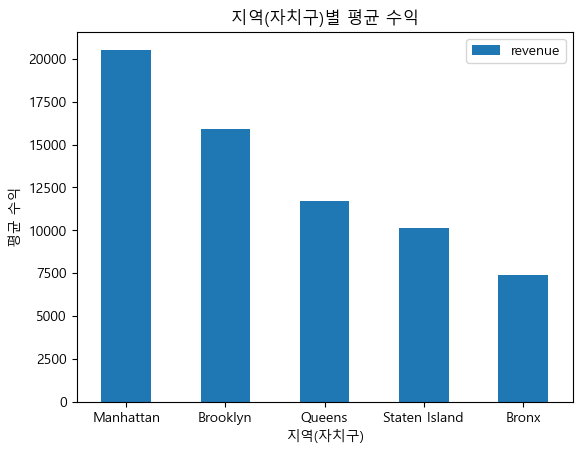

In [140]:
#시각화
revenue_pivot.sort_values(by='revenue',ascending=False).plot(kind='bar')
plt.title('지역(자치구)별 평균 수익')
plt.xlabel('지역(자치구)')
plt.ylabel('평균 수익')
plt.xticks(rotation=0) 
plt.show()



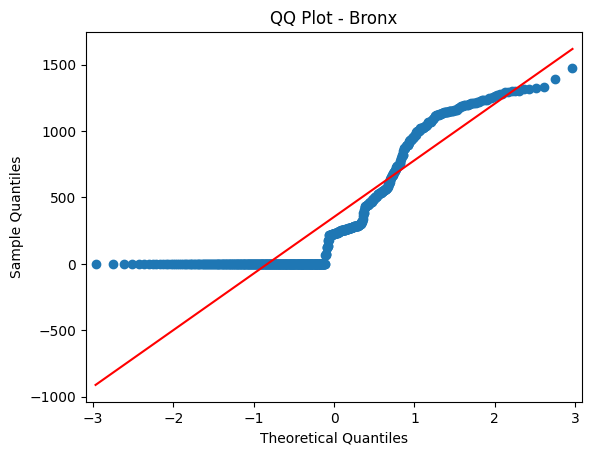

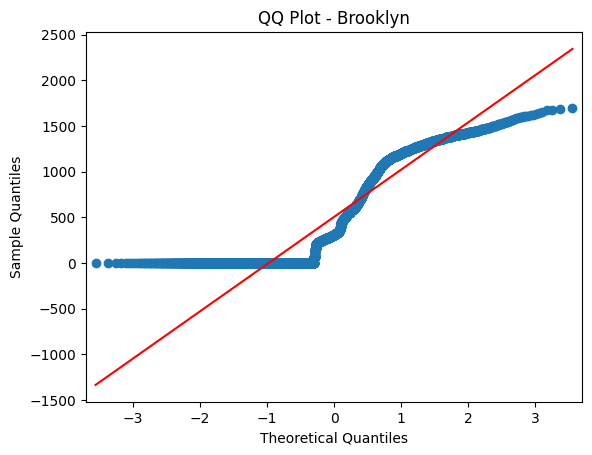

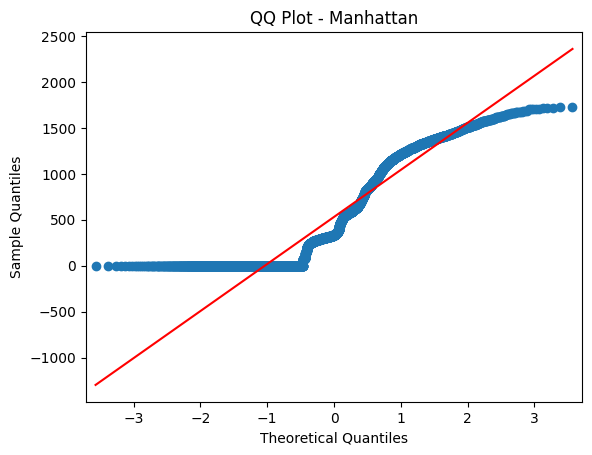

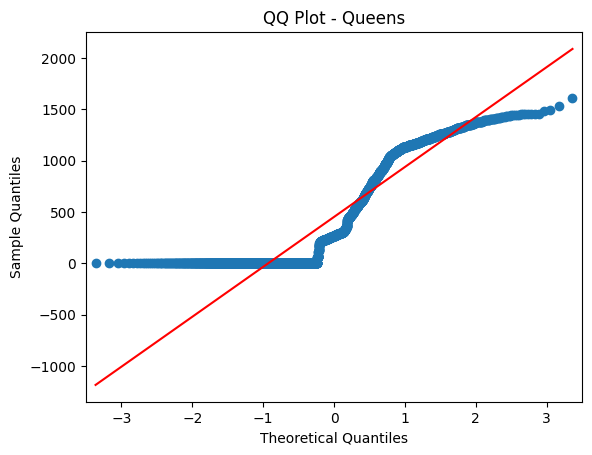

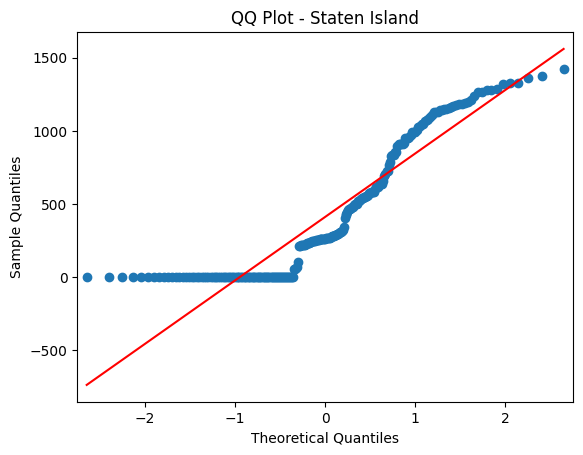

In [113]:
import statsmodels.api as sm
import matplotlib.pyplot as plt



for name, group in df.groupby('neighbourhood_group_cleansed')['log_revenue']:
    sm.qqplot(group, line='s')
    plt.title(f"QQ Plot - {name}")
    plt.show()

In [141]:
# 정규성 어긋나므로 비모수 검정: Kruskal-Wallis test
from scipy import stats

# 1. 자치구(neighbourhood_group_cleansed) 목록 추출
groups = df['neighbourhood_group_cleansed'].unique()

# 2. 각 자치구별 revenue 데이터를 리스트로 묶기

revenue_by_group = [df[df['neighbourhood_group_cleansed'] == g]['revenue'] for g in groups]

# 3. 비모수 검정 수행
stat, p_value = stats.kruskal(*revenue_by_group)

print(f"통계량(H-statistic): {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 4. 결과 해석
if p_value < 0.05:
    print("결과: 자치구별 수익(revenue) 중앙값에 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결과: 자치구별 수익(revenue) 중앙값에 유의미한 차이가 있다고 보기 어렵습니다.")

통계량(H-statistic): 289.9727
p-value: 0.0000
결과: 자치구별 수익(revenue) 중앙값에 통계적으로 유의미한 차이가 있습니다.


## 지역별 평균 예약률

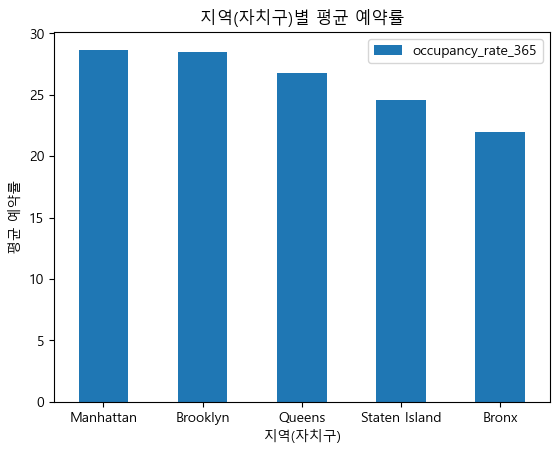

In [142]:
df['occupancy_rate_365'] = (df['estimated_occupancy_l365d'] / 365) * 100


o_pivot = pd.pivot_table(df, index='neighbourhood_group_cleansed', values='occupancy_rate_365', aggfunc= 'mean')
o_pivot

o_pivot.sort_values(by='occupancy_rate_365',ascending=False).plot(kind='bar')
plt.title('지역(자치구)별 평균 예약률')
plt.xlabel('지역(자치구)')
plt.ylabel('평균 예약률')
plt.xticks(rotation=0) 
plt.show()

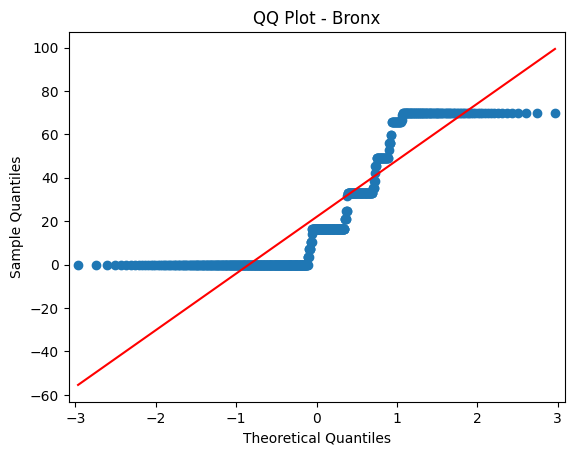

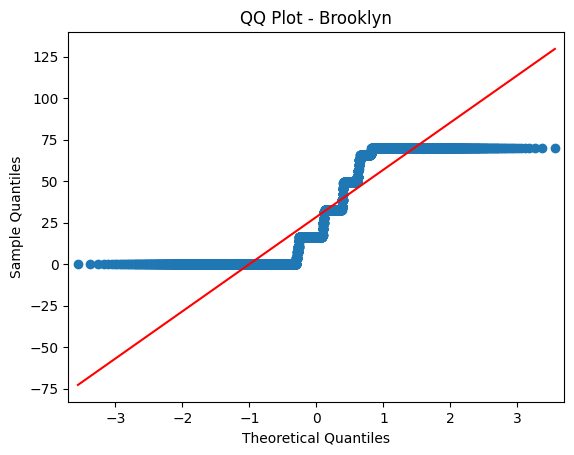

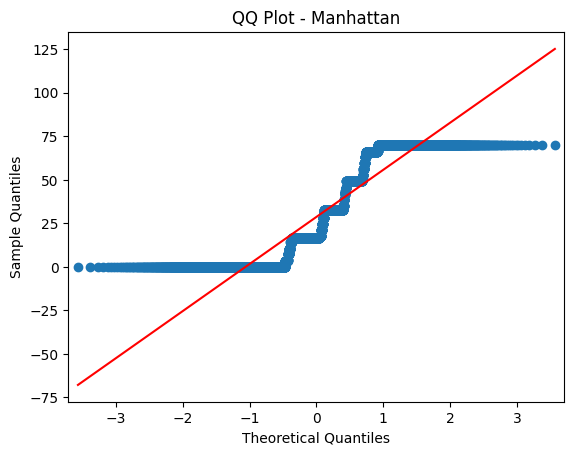

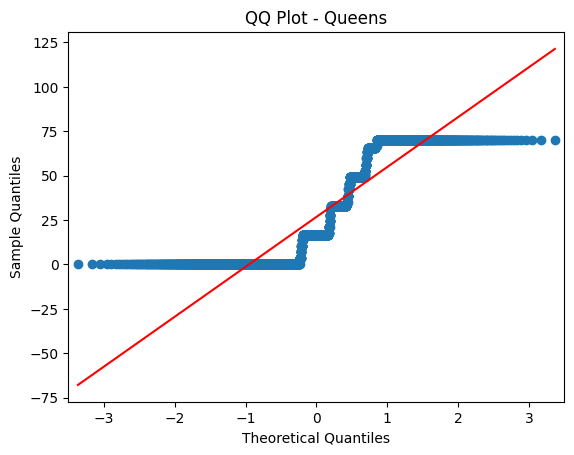

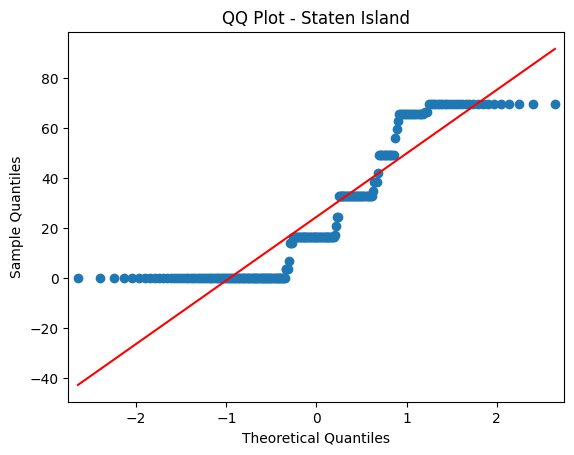

In [96]:
#qq플랏
import statsmodels.api as sm
import matplotlib.pyplot as plt

for name, group in df.groupby('neighbourhood_group_cleansed')['occupancy_rate_365']:
    sm.qqplot(group, line='s')
    plt.title(f"QQ Plot - {name}")
    plt.show()

In [119]:
# 정규성 위반하므로 비모수 검정: Kruskal-Wallis test

from scipy import stats

# 1. 자치구(neighbourhood_group_cleansed) 목록 추출
groups = df['neighbourhood_group_cleansed'].unique()

# 2. 각 자치구별 occupancy_rate_365 데이터를 리스트로 묶기
# revenue 대신 제공해주신 예약률 컬럼을 사용합니다.
occupancy_by_group = [df[df['neighbourhood_group_cleansed'] == g]['occupancy_rate_365'] for g in groups]

# 3. 비모수 검정(Kruskal-Wallis test) 수행
stat, p_value = stats.kruskal(*occupancy_by_group)

print(f"통계량(H-statistic): {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 4. 결과 해석
if p_value < 0.05:
    print("결과: 자치구별 예약률(occupancy_rate_365) 중앙값에 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결과: 자치구별 예약률(occupancy_rate_365) 중앙값에 유의미한 차이가 있다고 보기 어렵습니다.")

통계량(H-statistic): 51.9470
p-value: 0.0000
결과: 자치구별 예약률(occupancy_rate_365) 중앙값에 통계적으로 유의미한 차이가 있습니다.


## 지역별 숙소 개수(공급)

In [97]:
#지역별 숙소 개수
pivot1 = pd.pivot_table(df, index='neighbourhood_group_cleansed', values='id', aggfunc= 'count')
pivot1 

,id
neighbourhood_group_cleansed,
Bronx,664
Brooklyn,5342
Manhattan,5577
Queens,2598
Staten Island,245


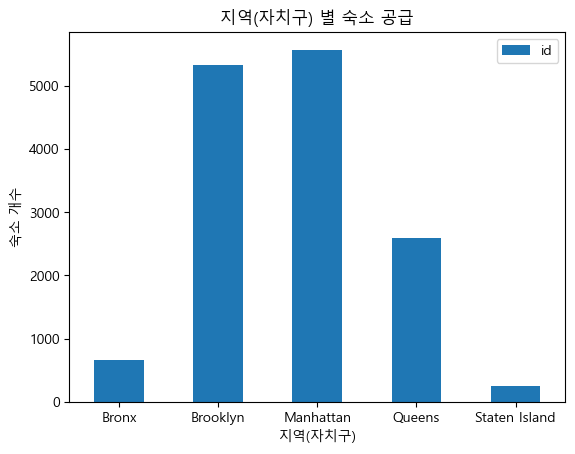

In [143]:
pivot1.plot(kind='bar')
plt.title('지역(자치구) 별 숙소 공급')
plt.xlabel('지역(자치구)')
plt.ylabel('숙소 개수')
plt.xticks(rotation=0) 
plt.show()

## 종합

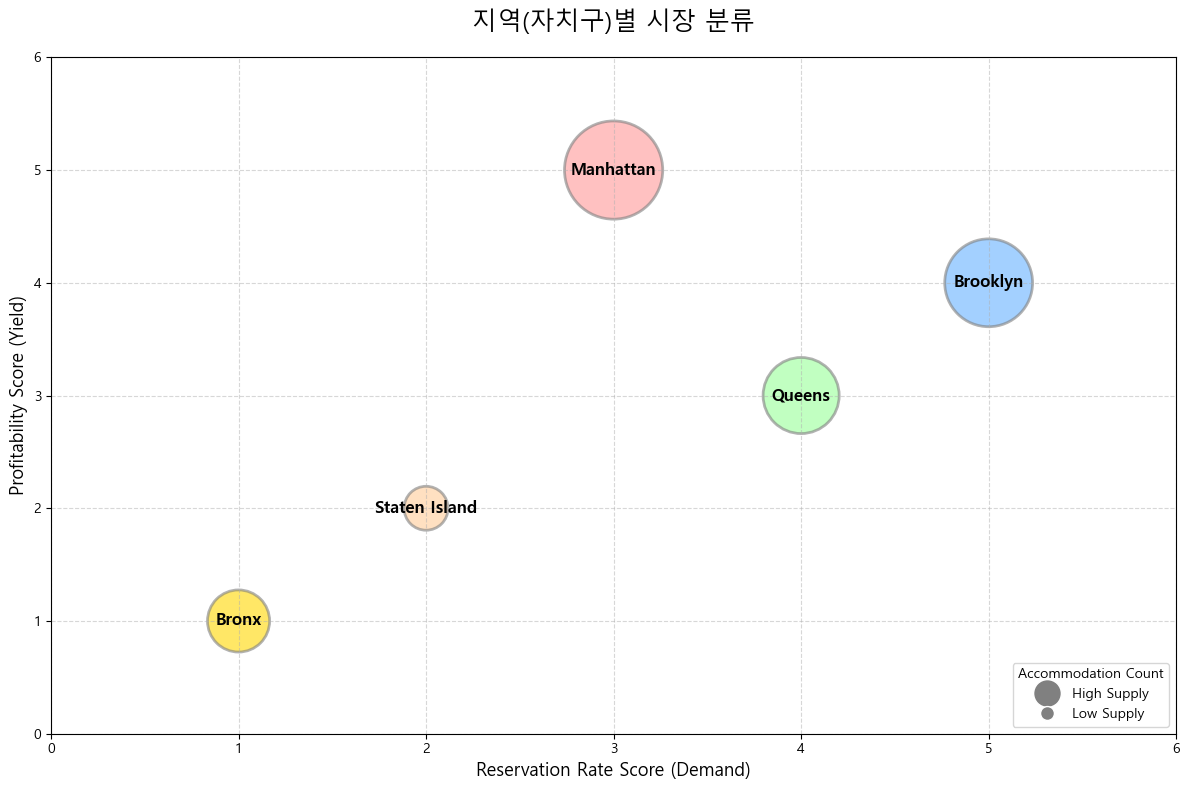

In [145]:
# 1. 데이터 준비 (제공해주신 순위를 5점 만점 척도로 변환)
# 1위: 5점, 2위: 4점, 3위: 3점, 4위: 2점, 5위: 1점
data = {
    'Borough': ['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx'],
    'Price_Score': [5, 4, 2, 3, 1],        # 가격 순위
    'Profit_Score': [5, 4, 3, 2, 1],       # 수익률 순위
    'Reservation_Score': [3, 5, 4, 2, 1],  # 예약률 순위
    'Count_Score': [5, 4, 3, 1, 2]         # 숙소 개수 순위
}

data = pd.DataFrame(data)

# 2. 시각화 설정
plt.figure(figsize=(12, 8))

# 자치구별 고유 색상 설정
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700']

# 거품 크기 설정 (숙소 개수 점수에 가중치를 주어 시각화)
bubble_size = data['Count_Score'] * 1000 

# 3. 거품 차트 그리기
# X축: 예약률, Y축: 수익률
scatter = plt.scatter(
    data['Reservation_Score'], 
    data['Profit_Score'], 
    s=bubble_size, 
    c=colors, 
    alpha=0.6, 
    edgecolors="grey", 
    linewidth=2
)

# 4. 각 거품에 자치구 이름 표시
for i, txt in enumerate(data['Borough']):
    plt.annotate(
        txt, 
        (data['Reservation_Score'][i], data['Profit_Score'][i]), 
        fontsize=12, 
        ha='center', 
        va='center', 
        fontweight='bold'
    )


plt.title('지역(자치구)별 시장 분류', fontsize=18, pad=20)
plt.xlabel('Reservation Rate Score (Demand)', fontsize=13)
plt.ylabel('Profitability Score (Yield)', fontsize=13) 
plt.grid(True, linestyle='--', alpha=0.5)


plt.xlim(0, 6)
plt.ylim(0, 6)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='High Supply', markerfacecolor='gray', markersize=20),
    plt.Line2D([0], [0], marker='o', color='w', label='Low Supply', markerfacecolor='gray', markersize=10)
]
plt.legend(handles=legend_elements, loc='lower right', title="Accommodation Count")

plt.tight_layout()
plt.show() 

In [146]:
# 1. 자치구별 점수 설정
# 가격, 수익률, 예약률 점수를 딕셔너리로 정의
borough_stats = {
    'Manhattan': {'Price': 5, 'Profit': 5, 'Res': 3},
    'Brooklyn': {'Price': 4, 'Profit': 4, 'Res': 5},
    'Queens': {'Price': 2, 'Profit': 3, 'Res': 4},
    'Staten Island': {'Price': 3, 'Profit': 2, 'Res': 2},
    'Bronx': {'Price': 1, 'Profit': 1, 'Res': 1}
}

# 2. 종합 점수(Total Score) 계산 함수
# 각 자치구의 점수를 합산 (최대 15점)
for b in borough_stats:
    stats = borough_stats[b]
    borough_stats[b]['Total_Score'] = stats['Price'] + stats['Profit'] + stats['Res']


def get_total_group(borough):
    score = borough_stats.get(borough, {}).get('Total_Score', 0)
    
    if score >= 12:
        return 'Tier 1: High-Performance (프리미엄 시장)' # 맨해튼, 브루클린
    elif score >= 8:
        return 'Tier 2: High-Efficiency (가성비 시장)'    # 퀸즈
    else:
        return 'Tier 3: Emerging/Underperforming (저발전 시장)'   # 스테튼, 브롱크스

# 원본 df에 새로운 컬럼 추가
df['Market_Tier'] = df['neighbourhood_group_cleansed'].apply(get_total_group)


## 슈퍼호스트 여부와 예약률의 상관관계

In [147]:
#호스트 관련 컬럼 결측치 제거 및 확인 
df_host = df.dropna(subset=['host_is_superhost','host_response_time', 'host_response_rate', 'host_acceptance_rate', 'log_price']).copy()
df_host['superhost'] = df_host['host_is_superhost'].apply(lambda x: 1 if x == 't' else 0)
df_host.isnull().sum() 

Unnamed: 0.1                                       0
id                                                 0
name                                               0
description                                      157
neighborhood_overview                           4336
host_id                                            0
host_name                                          0
host_since                                         0
host_location                                   2262
host_about                                      4221
host_response_time                                 0
host_response_rate                                 0
host_acceptance_rate                               0
host_is_superhost                                  0
host_neighbourhood                              2285
host_listings_count                                0
host_total_listings_count                          0
host_verifications                                 0
host_has_profile_pic                          

In [148]:
superhost_pivot = pd.pivot_table(df_host, index='host_is_superhost', values='occupancy_rate_365', aggfunc = 'mean')
superhost_pivot.round(2)

,occupancy_rate_365
host_is_superhost,
f,25.15
t,44.49


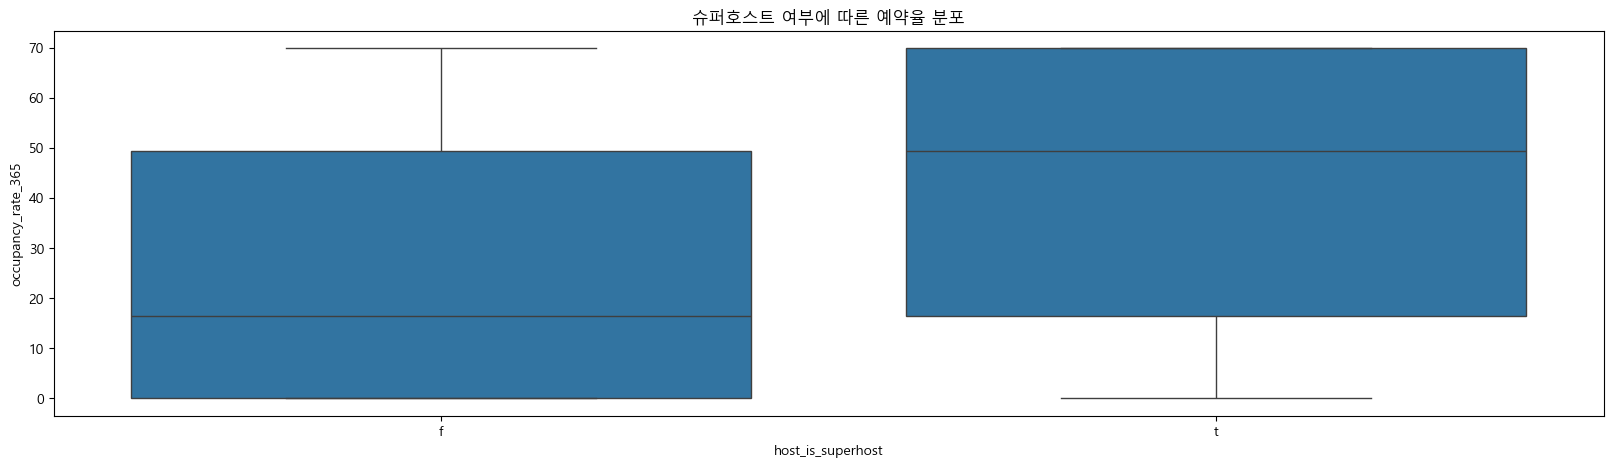

In [152]:
plt.figure(figsize=(20, 5))
sns.boxplot(x = 'host_is_superhost', y = 'occupancy_rate_365', data= df_host).set_title('슈퍼호스트 여부에 따른 예약율 분포')
plt.show()

In [124]:
# 등분산 검정 
groups = []
for name, g in df_host.groupby(['host_is_superhost']):
    arr = g['occupancy_rate_365'].values
    groups.append(arr)

stat, p = levene(*groups)
print("Levene stat:", stat, "p-value:", p)

Levene stat: 44.10193112087771 p-value: 3.263723650498228e-11


In [126]:
# welch t-test - 압도적 차이 
from scipy.stats import ttest_ind
x1 = groups[0]
x2 = groups[1]
print(f'검정 통계치 : {np.round(ttest_ind(x1, x2, equal_var = False)[0],3)}\np값 : {ttest_ind(x1, x2, equal_var = False)[1]}')

검정 통계치 : -39.409
p값 : 0.0


## market tier별 인원수와 가격의 상관관계 분석

In [127]:
# 2-1. 1인당 숙박 요금 효율성 계산
df['price_per_person'] = df['price'] / df['accommodates']

# 2-2. 그룹별 인원수(accommodates)와 가격의 상관관계 분석
print("--- 그룹별 인원수 1명 추가 시 가격 민감도 ---")
for tier in df['Market_Tier'].unique():
    subset = df[df['Market_Tier'] == tier]
    correlation = subset['accommodates'].corr(subset['price'])
    avg_ppp = subset['price_per_person'].mean()
    print(f"[{tier}] 인원-가격 상관계수: {correlation:.2f} | 1인당 평균 단가: ${avg_ppp:.2f}")


--- 그룹별 인원수 1명 추가 시 가격 민감도 ---
[Tier 1: High-Performance (Premium)] 인원-가격 상관계수: 0.52 | 1인당 평균 단가: $70.44
[Tier 2: High-Efficiency (Value)] 인원-가격 상관계수: 0.60 | 1인당 평균 단가: $49.02
[Tier 3: Emerging/Underperforming] 인원-가격 상관계수: 0.54 | 1인당 평균 단가: $46.62


## review 점수와 예약률의 상관관계

In [131]:
#review 중 'No Rating' 제외하고 실존하는 값만 가져오기
review_cols = ['review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location'
]

for col in review_cols:
    df = df[df[col] != 'No Rating']
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=review_cols)

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


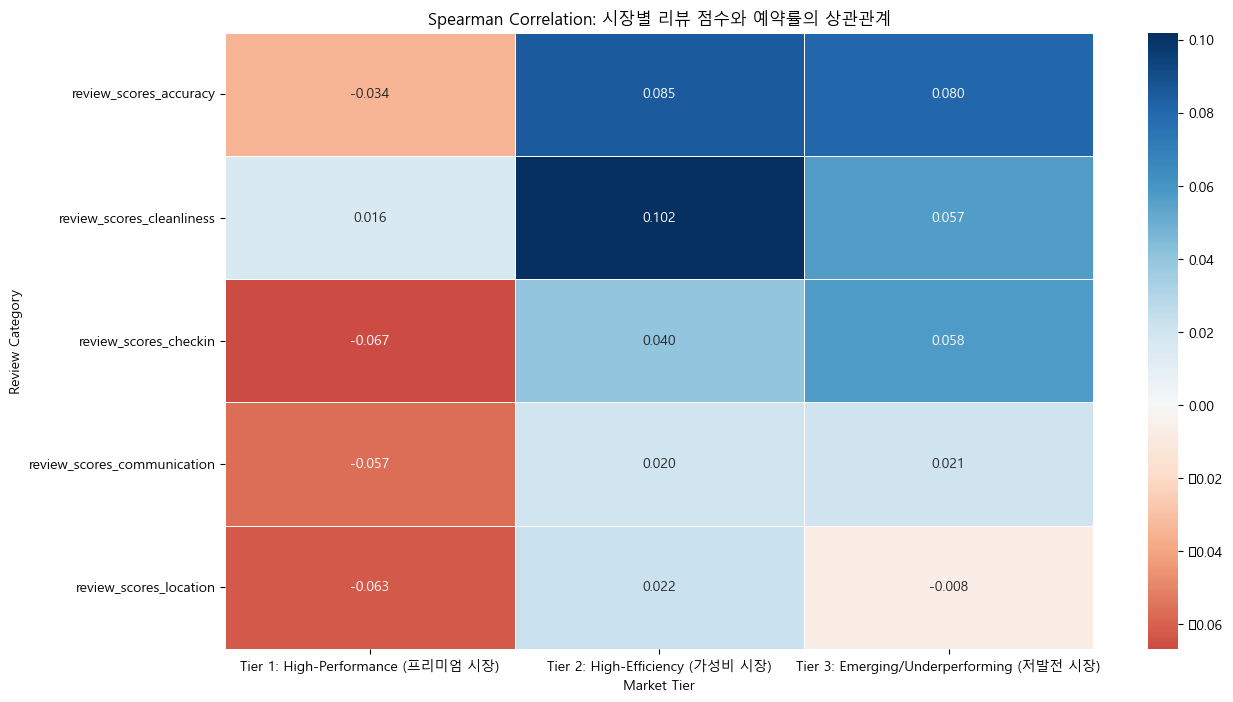

In [157]:
#스피어만 상관계수 히트맵 
corr_list = []
unique_tiers = df['Market_Tier'].unique()

for tier in unique_tiers:
    subset = df[df['Market_Tier'] == tier]
    corrs = subset[review_cols + ['occupancy_rate_365']].corr(method='spearman')['occupancy_rate_365'].drop('occupancy_rate_365')
    corrs.name = tier
    corr_list.append(corrs)


corr_matrix = pd.concat(corr_list, axis=1)

plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu', 
            center=0, 
            fmt=".3f", 
            linewidths=.5)

plt.title('Spearman Correlation: 시장별 리뷰 점수와 예약률의 상관관계')
plt.xlabel('Market Tier')
plt.ylabel('Review Category')
plt.xticks(rotation=0)
plt.show()

In [158]:
# 스피어만 상관계수: p-value 계산
import pandas as pd
from scipy import stats


test_results = []
unique_tiers = df['Market_Tier'].unique()

for tier in unique_tiers:
    subset = df[df['Market_Tier'] == tier]
    
    for col in review_cols:

        rho, pval = stats.spearmanr(subset[col], subset['occupancy_rate_365'], nan_policy='omit')
        
        test_results.append({
            'Market_Tier': tier,
            'Review_Category': col,
            'Correlation': round(rho, 4),
            'P-Value': round(pval, 4),
            'Is_Significant': pval < 0.05  
        })

# 3. 결과 테이블 생성 및 출력
results_table = pd.DataFrame(test_results)
print(results_table)

                                  Market_Tier              Review_Category  \
0          Tier 1: High-Performance (프리미엄 시장)       review_scores_accuracy   
1          Tier 1: High-Performance (프리미엄 시장)    review_scores_cleanliness   
2          Tier 1: High-Performance (프리미엄 시장)        review_scores_checkin   
3          Tier 1: High-Performance (프리미엄 시장)  review_scores_communication   
4          Tier 1: High-Performance (프리미엄 시장)       review_scores_location   
5            Tier 2: High-Efficiency (가성비 시장)       review_scores_accuracy   
6            Tier 2: High-Efficiency (가성비 시장)    review_scores_cleanliness   
7            Tier 2: High-Efficiency (가성비 시장)        review_scores_checkin   
8            Tier 2: High-Efficiency (가성비 시장)  review_scores_communication   
9            Tier 2: High-Efficiency (가성비 시장)       review_scores_location   
10  Tier 3: Emerging/Underperforming (저발전 시장)       review_scores_accuracy   
11  Tier 3: Emerging/Underperforming (저발전 시장)    review_scores_c